In [22]:
import os
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.utils import dense_to_sparse
from torch_geometric.nn import global_mean_pool, global_max_pool
from torch_geometric.nn import NNConv, CGConv, GCNConv, GATConv, GATv2Conv

from pymatgen.core import Structure, PeriodicSite, DummySpecie, Composition, Element
from pymatgen.core.periodic_table import Element as PMGElement
from pymatgen.analysis.local_env import MinimumDistanceNN
from pymatgen.util import coord as puc
from pymatgen.symmetry.analyzer import SpacegroupAnalyzer
from pymatgen.io.cif import CifWriter
from pymatgen.io.ase import AseAtomsAdaptor
from ase.visualize.plot import plot_atoms


from graphy_cvae import get_full_defective, get_nodes, get_edges, get_features
from graphy_cvae import get_mask, get_globals, get_cloud, get_graphs

original_data = "original_dataset"
final_data = "Final_Dataset"
gen_data = "Generated_Structures"

## Data Prep

In [23]:
# The whole dataset
comb_df = pd.read_csv(f"{final_data}/combined/combined_data.csv")
# sample_df = comb_df.sample(10, random_state=42)

# Sample row
an_index = random.randint(0, len(comb_df)-1)
a_row = comb_df.iloc[an_index]
# sample_row = sample_df.iloc[0]

# Get required attributes from sample row
a_dataset_material = a_row["dataset_material"]
a_material = a_dataset_material.split("_")[1]
an_id = a_row["_id"]
a_bgv = a_row["band_gap_value"]

# Get defective structure
a_defective_file_path = f"{original_data}/{a_dataset_material}/cifs/{an_id}.cif"
a_defective_structure = Structure.from_file(a_defective_file_path)

# Get reference structure
a_ref_file_path = f"{final_data}/ref_cifs/{a_dataset_material}.cif"
a_reference_structure = Structure.from_file(a_ref_file_path)

a_full_defective_structure  = get_full_defective(a_reference_structure, a_defective_structure)
a_full_defective_nodes      = get_nodes(a_full_defective_structure)
a_full_defective_edges      = get_edges(a_full_defective_structure)
a_full_defective_E_features = get_features(a_full_defective_edges, a_full_defective_structure)
a_full_defective_mask       = get_mask(a_reference_structure)
a_full_defective_u          = get_globals(a_material, a_bgv)

/home/amutua/inverse/lib/python3.10/site-packages/pymatgen/core/structure.py:3109: UserWarning: Issues encountered while parsing CIF: 45 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  struct = parser.parse_structures(primitive=primitive)[0]
/home/amutua/inverse/lib/python3.10/site-packages/pymatgen/core/structure.py:3109: UserWarning: Issues encountered while parsing CIF: 48 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  struct = parser.parse_structures(primitive=primitive)[0]


## Implimentation on the whole dataset

In [24]:
# ================================
# WHOLE DATA
# ================================
'''
train_set, val_set = train_test_split(comb_df, test_size=0.3, random_state=42, stratify=comb_df["strata"])

train_graphs = get_graphs(train_set)
val_graphs = get_graphs(val_set)

torch.save(train_graphs, "Final_Dataset/cvae models/cvae_train_graphs.pt")
torch.save(val_graphs, "Final_Dataset/cvae models/cvae_val_graphs.pt")
'''
# ===============================
# HIGH DATASET ONLY
# ===============================
'''
sample_df = comb_df[(comb_df["dataset_material"] != "low_MoS2") & (comb_df["dataset_material"] != "low_WSe2")]

sample_train, sample_val = train_test_split(sample_df, test_size=0.25, random_state=42, stratify=sample_df["strata"])

sample_train_graphs = get_graphs(sample_train)
sample_val_graphs = get_graphs(sample_val)

torch.save(sample_train_graphs, f"Final_Dataset/cvae models/high_cvae_train_graphs.pt")
torch.save(sample_val_graphs, f"Final_Dataset/cvae models/high_cvae_val_graphs.pt")
'''

# =============================
# HIGH MoS2 & HIGH WSe2
# =============================
'''
high_mos2_wse2_df = comb_df[(comb_df["dataset_material"] == "high_MoS2") & (comb_df["dataset_material"] == "high_WSe2")]

sample_train, sample_val = train_test_split(high_mos2_wse2_df, test_size=0.25, random_state=42, stratify=high_mos2_wse2_df["strata"])

sample_train_graphs = get_graphs(sample_train)
sample_val_graphs = get_graphs(sample_val)

torch.save(sample_train_graphs, "Final_Dataset/cvae models/high_cvae_train_graphs.pt")
torch.save(sample_val_graphs, "Final_Dataset/cvae models/high_cvae_val_graphs.pt")
'''

'\nhigh_mos2_wse2_df = comb_df[(comb_df["dataset_material"] == "high_MoS2") & (comb_df["dataset_material"] == "high_WSe2")]\n\nsample_train, sample_val = train_test_split(high_mos2_wse2_df, test_size=0.25, random_state=42, stratify=high_mos2_wse2_df["strata"])\n\nsample_train_graphs = get_graphs(sample_train)\nsample_val_graphs = get_graphs(sample_val)\n\ntorch.save(sample_train_graphs, "Final_Dataset/cvae models/high_cvae_train_graphs.pt")\ntorch.save(sample_val_graphs, "Final_Dataset/cvae models/high_cvae_val_graphs.pt")\n'

In [4]:
# Load graphs
full_train_graphs = torch.load("Final_Dataset/cvae models/cvae_train_graphs.pt", weights_only=False)
full_val_graphs = torch.load("Final_Dataset/cvae models/cvae_val_graphs.pt", weights_only=False)

high_train_graphs = torch.load("Final_Dataset/cvae models/high_cvae_train_graphs.pt", weights_only=False)
high_val_graphs = torch.load("Final_Dataset/cvae models/high_cvae_val_graphs.pt", weights_only=False)


# Create data loaders
full_train_loader = DataLoader(full_train_graphs, batch_size=1, shuffle=True) 
full_val_loader   = DataLoader(full_val_graphs, batch_size=1, shuffle=False)

high_train_loader = DataLoader(high_train_graphs, batch_size=1, shuffle=True) 
high_val_loader   = DataLoader(high_val_graphs, batch_size=1, shuffle=False)

# Visualize the shape of the data
for batch in full_train_loader:
    print(f"Full data sample: {batch}")
    break

for batch in high_train_loader:
    print(f"High data sample: {batch}")
    break

Full data sample: DataBatch(x=[144, 19], edge_index=[2, 309], edge_attr=[309, 7], u=[1, 7], mask=[119], batch=[144], ptr=[2])
High data sample: DataBatch(x=[144, 19], edge_index=[2, 341], edge_attr=[341, 7], u=[1, 7], mask=[119], batch=[144], ptr=[2])


In [46]:
# sample_0 = full_train_loader.dataset[0]
sample_0 = high_train_loader.dataset[0]

NODE_DIM   = sample_0.x.shape[1] 
EDGE_DIM   = sample_0.edge_attr.shape[1] 
U_DIM      = sample_0.u.shape[1] 
MASK_DIM   = sample_0.mask.shape[0]

HIDDEN_DIM = 256
LATENT_DIM = 32

print(f"Node dim: {NODE_DIM}\nEdge dim: {EDGE_DIM}\nU dim: {U_DIM}\nMask Dim: {MASK_DIM}")

Node dim: 19
Edge dim: 7
U dim: 7
Mask Dim: 119


In [63]:
test_masking = sample_0.x

orig_Z = (test_masking[..., 10] * 94).round().long().clamp(0, 118)
new_Z  = (test_masking[..., 3] * 94).round().long().clamp(0, 118)

# Sites
site_targets    = (new_Z != orig_Z).float()
s_mask = site_targets.unsqueeze(-1)

# Species
species_targets = new_Z.clamp(min=0).long()
species_mask = []

for z in species_targets:
    one_hot = [1 if i == z else 0 for i in range(119)]
    species_mask.append(one_hot)

sp_mask = torch.tensor(species_mask)

# Concatenate
s_sp_mask = torch.cat([s_mask, sp_mask], dim=-1)

## The model architecture

## Encoder

In [71]:
# Encoder
class CVAE_Encoder(nn.Module):
    def __init__(self, node_dim, edge_dim, u_dim, hidden_dim, latent_dim):
        super().__init__()

        # self.edge_nn = nn.Sequential(nn.Linear(edge_dim, 64),nn.ReLU(),nn.Linear(64, node_dim * hidden_dim))
        # self.conv0 = NNConv(node_dim, hidden_dim, self.edge_nn, aggr='mean')

        self.dropout = nn.Dropout(p=0.1)

        # Learn crystal graph properties
        self.conv0 = GATv2Conv(node_dim, hidden_dim, edge_dim=edge_dim)
        self.conv1 = GCNConv(hidden_dim, 128)
        self.conv2 = GCNConv(128, 64)

        # Learn global properties
        self.global_embed = nn.Linear(u_dim, 64)

        # Learn defect cloud
        self.learn_cloud = nn.Linear(120,64)
        
        self.linear1 = nn.Linear(64*4, 64*3)
        self.linear2 = nn.Linear(64*3, 64*2)
        self.linear3 = nn.Linear(64*2, 64)

        self.fc_mu      = nn.Linear(64, latent_dim)
        self.fc_log_var = nn.Linear(64, latent_dim)

    def forward(self, data):
        start_x, edge_index, edge_attr, batch, u= (
            data.x,
            data.edge_index,
            data.edge_attr,
            data.batch,
            data.u
        )

        x = F.relu(self.conv0(start_x, edge_index, edge_attr))
        x = F.relu(self.conv1(x, edge_index))
        x = F.relu(self.conv2(x, edge_index))

        x_mean = global_mean_pool(x, batch)
        x_max  = global_max_pool(x,batch)

        u = self.global_embed(u)

        x = torch.cat([x_max, x_mean], dim=1)
        x = torch.cat([x,u], dim=1)

        orig_Z = (start_x[..., 10] * 94).round().long().clamp(0, 118)
        new_Z  = (start_x[..., 3] * 94).round().long().clamp(0, 118)
        
        # Sites
        site_targets    = (new_Z != orig_Z).float()
        s_mask = site_targets.unsqueeze(-1)
        
        # Species
        species_targets = new_Z.clamp(min=0).long()
        species_mask = []
        
        for z in species_targets:
            one_hot = [1 if i == z else 0 for i in range(119)]
            species_mask.append(one_hot)
        
        sp_mask = torch.tensor(species_mask)
        
        # Concatenate
        s_sp_mask = torch.cat([s_mask, sp_mask], dim=-1)

        masking = F.relu(self.learn_cloud(s_sp_mask))

        x_expand = masking.shape[0]
        x = x.expand(x_expand, -1)
        x = torch.cat([x, masking], dim=-1)

        

        x = F.relu(self.linear1(x))
        x = F.relu(self.linear2(x))
        x = F.relu(self.linear3(x))
        x = self.dropout(x)
        
        mu      = self.fc_mu(x) 
        log_var = self.fc_log_var(x)

        mu = mu.mean(dim=0, keepdim=True)
        log_var = log_var.mean(dim=0, keepdim=True)
        
        return mu, log_var

for the_sample in high_train_loader:
# for the_sample in full_train_loader:

    # MAX = the_sample.x.shape[0]

    # Test encoder
    test_encoder = CVAE_Encoder(NODE_DIM, EDGE_DIM, U_DIM, HIDDEN_DIM, LATENT_DIM)
    out_mu, out_log_var = test_encoder(the_sample)
    print("TESTING ENCODER\n")
    
    print("Mu shape:", out_mu.shape)
    print("Mu sample:\n", out_mu)
    
    print("\nLog var shape:", out_log_var.shape)
    print("Log var Sample:\n", out_log_var)

    break

TESTING ENCODER

Mu shape: torch.Size([1, 32])
Mu sample:
 tensor([[ 0.0160, -0.0881, -0.0517,  0.0746, -0.1045, -0.0544,  0.1267,  0.0979,
          0.1059, -0.0598, -0.0270,  0.0881,  0.0576, -0.0176,  0.0512,  0.0937,
          0.0041, -0.0806, -0.1030,  0.0604, -0.0200,  0.0078,  0.0356,  0.0647,
          0.0253,  0.0786,  0.1346,  0.0550,  0.0236,  0.1141,  0.0732,  0.1103]],
       grad_fn=<MeanBackward1>)

Log var shape: torch.Size([1, 32])
Log var Sample:
 tensor([[ 0.1142,  0.0309,  0.0634,  0.1390, -0.0296, -0.0828,  0.0058,  0.0443,
          0.0284,  0.0415,  0.0640, -0.0522, -0.1460, -0.0573,  0.0061,  0.0649,
          0.0084, -0.0349, -0.1583, -0.0110,  0.0968, -0.0351,  0.0275, -0.0364,
         -0.0403, -0.0753,  0.0258,  0.0058,  0.1676,  0.0585,  0.0455,  0.0008]],
       grad_fn=<MeanBackward1>)


## Decoder

In [73]:
# Decoder
class CVAE_Decoder(nn.Module):
    def __init__(self, hidden_dim, latent_dim, mask_dim, u_dim, max_sites=192):
        super().__init__()

        self.mask_dim       = mask_dim
        self.hidden_dim     = hidden_dim

        self.seq1 = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.ReLU()
        )

        self.global_embed = nn.Linear(u_dim, 32)

        self.seq2 = nn.Sequential(
            nn.Linear(128 + 32, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
        )

        self.site_embedding = nn.Embedding(max_sites, 32)

        self.seq3 = nn.Sequential(
            nn.Linear(hidden_dim + 32 , hidden_dim * 2),
            nn.ReLU(),
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1 + mask_dim),
        )


    def forward(self, z, condition_vector, out_sites, the_masking):         
        x = self.seq1(z)                         
        u = self.global_embed(condition_vector)     

        x = torch.cat([x,u], dim=-1)                

        x = self.seq2(x)                            
        x = x.expand(out_sites, -1)  

        # Unique embedding per site      
        site_idx = torch.arange(out_sites, device=z.device) 
        site_emb = self.site_embedding(site_idx)   

        # Concatenate
        per_site_input = torch.cat([x, site_emb], dim=-1)  

        recon = self.seq3(per_site_input)


        # CLEAN THE RECONSTRUCTED TENSOR
        defect_status  = recon[:, 0:1]        
        species_logits = recon[:, 1:] 

        # Apply mask
        mask = species_logits.unsqueeze(0).masked_fill(~the_masking.unsqueeze(0), -1e9)
        mask = mask.squeeze()

        fine_recon = torch.cat([defect_status, mask], dim=-1) 

        return fine_recon 


def reparameterize(mu, log_var):
    std = torch.exp(0.5 * log_var)
    eps = torch.randn_like(std)
    z = mu + eps * std
    return z

# Test with first batch from loader
# for the_sample in full_train_loader:
for the_sample in high_train_loader:
    MAX = the_sample.x.shape[0]

    # Encoder part
    # test_encoder = CVAE_Encoder(NODE_DIM, EDGE_DIM, U_DIM, HIDDEN_DIM, LATENT_DIM)
    # out_mu, out_log_var = test_encoder(the_sample)
    
    # out_z = reparameterize(out_mu, out_log_var)
    # out_z = out_mu
    out_z = torch.randn(1, 32) # , device=device)
    
    test_decoder = CVAE_Decoder(HIDDEN_DIM, LATENT_DIM, MASK_DIM, U_DIM)
    out_decoder = test_decoder(out_z, the_sample.u, MAX, the_sample.mask)
    print("TESTING DECODER")
    print("Decoder output shape:", out_decoder.shape)    
    break

TESTING DECODER
Decoder output shape: torch.Size([144, 120])


## Actual Model

In [74]:
# ACTUAL MODEL(ENCODER + DECODER)
class DefectCVAE(nn.Module):
    def __init__(self, node_dim, mask_dim, edge_dim, u_dim, hidden_dim, latent_dim):
        super().__init__()
        self.node_dim   = node_dim
        self.mask_dim   = mask_dim
        
        self.encoder = CVAE_Encoder(node_dim, edge_dim, u_dim, hidden_dim, latent_dim)
        self.decoder = CVAE_Decoder(hidden_dim, latent_dim, mask_dim, u_dim)

    def reparameterize(self, mu, log_var):
        std = torch.exp(0.5 * log_var)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, data):
        mu, log_var = self.encoder(data)
        
        if self.training:
            z = self.reparameterize(mu, log_var)
        else:
            z = mu
            
        out_sites = data.x.shape[0]
        recon = self.decoder(z, data.u, out_sites, data.mask)
        
        return recon, mu, log_var

# Test with first batch from loader
# for batch in full_train_loader:
for batch in high_train_loader:
    the_sample = batch

    MAX = the_sample.x.shape[0]

    # Test full model
    test_model = DefectCVAE(NODE_DIM, MASK_DIM, EDGE_DIM, U_DIM, HIDDEN_DIM, LATENT_DIM)
    gen_structure_tensor, mu, log_var = test_model(the_sample)
    print("TESTING FULL MODEL")
    print("Reconstruction shape:", gen_structure_tensor.shape)    
    break

TESTING FULL MODEL
Reconstruction shape: torch.Size([192, 120])


### Loss Function

In [75]:
class LogCoshLoss(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, input, target):
        ey_t = input-target
        return torch.mean(torch.log(torch.cosh(ey_t + 1e-12)))

def cvae_loss(gen_structure_tensor, target_structure_tensor, ref_mask, mu, log_var, beta, device):

    gen_structure_tensor    = gen_structure_tensor.to(device)
    target_structure_tensor = target_structure_tensor.to(device)
    mu                      = mu.to(device)
    log_var                 = log_var.to(device)
    n_sites                 = target_structure_tensor.shape[0]

    # Predictions
    site_logits    = gen_structure_tensor[..., 0]
    species_logits = gen_structure_tensor[..., 1:]
    pred_num_defects = torch.sigmoid(site_logits).sum()
    # pred_num_onehot = [1 if pred_num_defects == count else 0 for count in possible_num_defects]
    # pred_num_onehot = torch.tensor(pred_num_onehot, dtype=float)

    # Targets
    orig_Z = (target_structure_tensor[..., 10] * 94).round().long().clamp(0, 118)
    new_Z  = (target_structure_tensor[..., 3] * 94).round().long().clamp(0, 118)

    site_targets    = (new_Z != orig_Z).float()
    species_targets = new_Z.clamp(min=0).long()
    target_num_defects = site_targets.sum()
    # target_num_onehot = [1 if target_num_defects == count else 0 for count in possible_num_defects]
    # target_num_onehot = torch.tensor(target_num_onehot, dtype=float)

    # =====================
    # Defects Count Loss
    # =====================
    loss_num_defects = nn.MSELoss()

    pred_count = pred_num_defects/n_sites
    target_count = target_num_defects/n_sites

    defects_num_loss = loss_num_defects(pred_count, target_count)

    # =====================
    # Site Loss
    # =====================
    site_penalty    = (n_sites/target_num_defects.float()).clamp(max=50)
    site_weights    = torch.tensor([site_penalty], dtype=torch.float, device=device)
    
    loss_site   = nn.BCEWithLogitsLoss(pos_weight=site_weights)
    site_loss   = loss_site(site_logits, site_targets)
    # site_loss    = F.binary_cross_entropy_with_logits(site_logits, site_targets, pos_weight=site_weights)
    

    # ======================
    # Species Loss
    # ======================

    defect_mask = site_targets.bool()
    # species_weights = torch.tensor(ref_mask, dtype=torch.float, device=device) * float(specie_penalty)
    loss_specie = nn.CrossEntropyLoss(weight=None) # species_weights)
    # species_loss = F.cross_entropy(species_logits, species_targets, weight=species_weights.expand(119))
    species_loss = loss_specie(species_logits[defect_mask], species_targets[defect_mask])

    # ======================
    # KL Loss
    # ======================

    kl_loss = -0.5 * torch.mean(1 + log_var - mu.pow(2) - log_var.exp())

    # ======================
    # Total Loss
    # ======================

    total = defects_num_loss + site_loss + species_loss + (beta * kl_loss)
    
    return total, defects_num_loss, site_loss, species_loss, kl_loss

# Test loss function
# for a_batch in full_train_loader:
for a_batch in high_train_loader:
    test_model = DefectCVAE(NODE_DIM, MASK_DIM, EDGE_DIM, U_DIM, HIDDEN_DIM, LATENT_DIM)
    recon, mu, log_var = test_model(a_batch)
    
    a,e,b,c,d = cvae_loss(recon, a_batch.x, a_batch.mask, mu, log_var, 1e-3, "cuda")
    print(f"total: {a}, defects_count_loss: {e}, site_loss: {b}, species_loss: {c}, kl_loss: {d}")

    break

total: 2.5382916927337646, defects_count_loss: 0.13200591504573822, site_loss: 1.2993344068527222, species_loss: 1.1069467067718506, kl_loss: 0.004522155970335007


## Training and Testing

In [76]:
# Training Function
def train_model(model, train_loader, cvae_loss, current_beta, device, optimizer):
    # Set the model in training mode
    model.train()

    # To track the losses
    t_loss, c_loss, s_loss, sp_loss, kl_loss = 0.0, 0.0, 0.0, 0.0, 0.0
    s_accuracy, sp_accuracy = 0.0, 0.0

    for batch in train_loader:
        optimizer.zero_grad()

        # Output of the model
        batch = batch.to(device)
        recon, mu, log_var = model(batch)
        
        NUM_SITES = batch.x.shape[0]
        gen_structure_tensor = recon.view((NUM_SITES, (1 + MASK_DIM)))

        # The loss (pass batch.mask and configured weight_penalty)
        t,c,s,sp,kl = cvae_loss(recon, batch.x, batch.mask, mu, log_var, current_beta, device)
        
        t.backward()
        # torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        t_loss  += t.item() * batch.num_graphs
        c_loss  += c.item() * batch.num_graphs
        s_loss  += s.item() * batch.num_graphs
        sp_loss += sp.item() * batch.num_graphs
        kl_loss += kl.item() * batch.num_graphs
        

    n = len(train_loader)
    t_losses = {"Total_loss": t_loss/n, "Defect_Count_loss": c_loss/n, "Site_loss": s_loss/n, "Species_loss": sp_loss/n, "KL_loss": kl_loss/n}

    return t_losses

def validate_model(model, val_loader, cvae_loss, current_beta, device):
    # Model in evaluation mode
    model.eval()
    
    t_loss, c_loss, s_loss, sp_loss, kl_loss = 0.0, 0.0, 0.0, 0.0, 0.0

    with torch.no_grad():
        for batch in val_loader:
            batch = batch.to(device)
            recon, mu, log_var = model(batch)
            NUM_SITES = batch.x.shape[0]
            recon = recon.view((NUM_SITES,(1 + MASK_DIM)))

            t,c,s,sp,kl = cvae_loss(recon, batch.x, batch.mask, mu, log_var, current_beta, device)

            t_loss += t.item() * batch.num_graphs
            c_loss += c.item() * batch.num_graphs
            s_loss += s.item() * batch.num_graphs
            sp_loss += sp.item() * batch.num_graphs
            kl_loss += kl.item() * batch.num_graphs

        n = len(val_loader)# .dataset)
        v_losses = {"Total_loss": t_loss/n, "Defect_Count_loss": c_loss/n, "Site_loss": s_loss/n, "Species_loss": sp_loss/n, "KL_loss": kl_loss/n}
        return v_losses

In [77]:
# Loaders for Full Dataset
# train_loader = full_train_loader 
# val_loader = full_val_loader 

# Loaders for Sample Dataset
train_loader = high_train_loader 
val_loader = high_val_loader 

# Parameters for training model
device    = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model     = DefectCVAE(NODE_DIM, MASK_DIM, EDGE_DIM, U_DIM, HIDDEN_DIM, LATENT_DIM).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=30, gamma=0.5)

EPOCHS = 20
beta   = 1e-3

train_metrics, val_metrics = [], []


for epoch in range(1, EPOCHS+1):
    print(f"Epoch {epoch:4d}")
    # Train
    current_beta = beta * min(1.0, epoch / EPOCHS)
    t_losses = train_model(model,train_loader, cvae_loss, current_beta, device, optimizer)

    # Validate
    val_losses = validate_model(model, val_loader, cvae_loss, current_beta, device)
    scheduler.step()

    # Store and print metrics
    train_metrics.append(t_losses)
    val_metrics.append(val_losses)
    
    print(f"Train      : {t_losses['Total_loss']:.4f} | {t_losses['Defect_Count_loss']:.4f} | {t_losses['Site_loss']:.4f} | {t_losses['Species_loss']:.4f} | {t_losses['KL_loss']:.4f}")
    print(f"Validation : {val_losses['Total_loss']:.4f} | {val_losses['Defect_Count_loss']:.4f} | {val_losses['Site_loss']:.4f} | {val_losses['Species_loss']:.4f} | {val_losses['KL_loss']:.4f}\n")

Epoch    1


/home/amutua/inverse/lib/python3.10/site-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(


RuntimeError: Expected all tensors to be on the same device, but got tensors is on cpu, different from other tensors on cuda:0 (when checking argument in method wrapper_CUDA_cat)

In [12]:
totals = [train_metrics[i]["Total_loss"] for i in range(len(train_metrics))]
counts = [train_metrics[i]["Defect_Count_loss"] for i in range(len(train_metrics))]
ss     = [train_metrics[i]["Site_loss"] for i in range(len(train_metrics))]
sps    = [train_metrics[i]["Species_loss"] for i in range(len(train_metrics))]
kls    = [train_metrics[i]["KL_loss"] for i in range(len(train_metrics))]

totals_v = [val_metrics[i]["Total_loss"] for i in range(len(val_metrics))]
counts_v = [val_metrics[i]["Defect_Count_loss"] for i in range(len(val_metrics))]
ss_v     = [val_metrics[i]["Site_loss"] for i in range(len(val_metrics))]
sps_v    = [val_metrics[i]["Species_loss"] for i in range(len(val_metrics))]
kls_v    = [val_metrics[i]["KL_loss"] for i in range(len(val_metrics))]

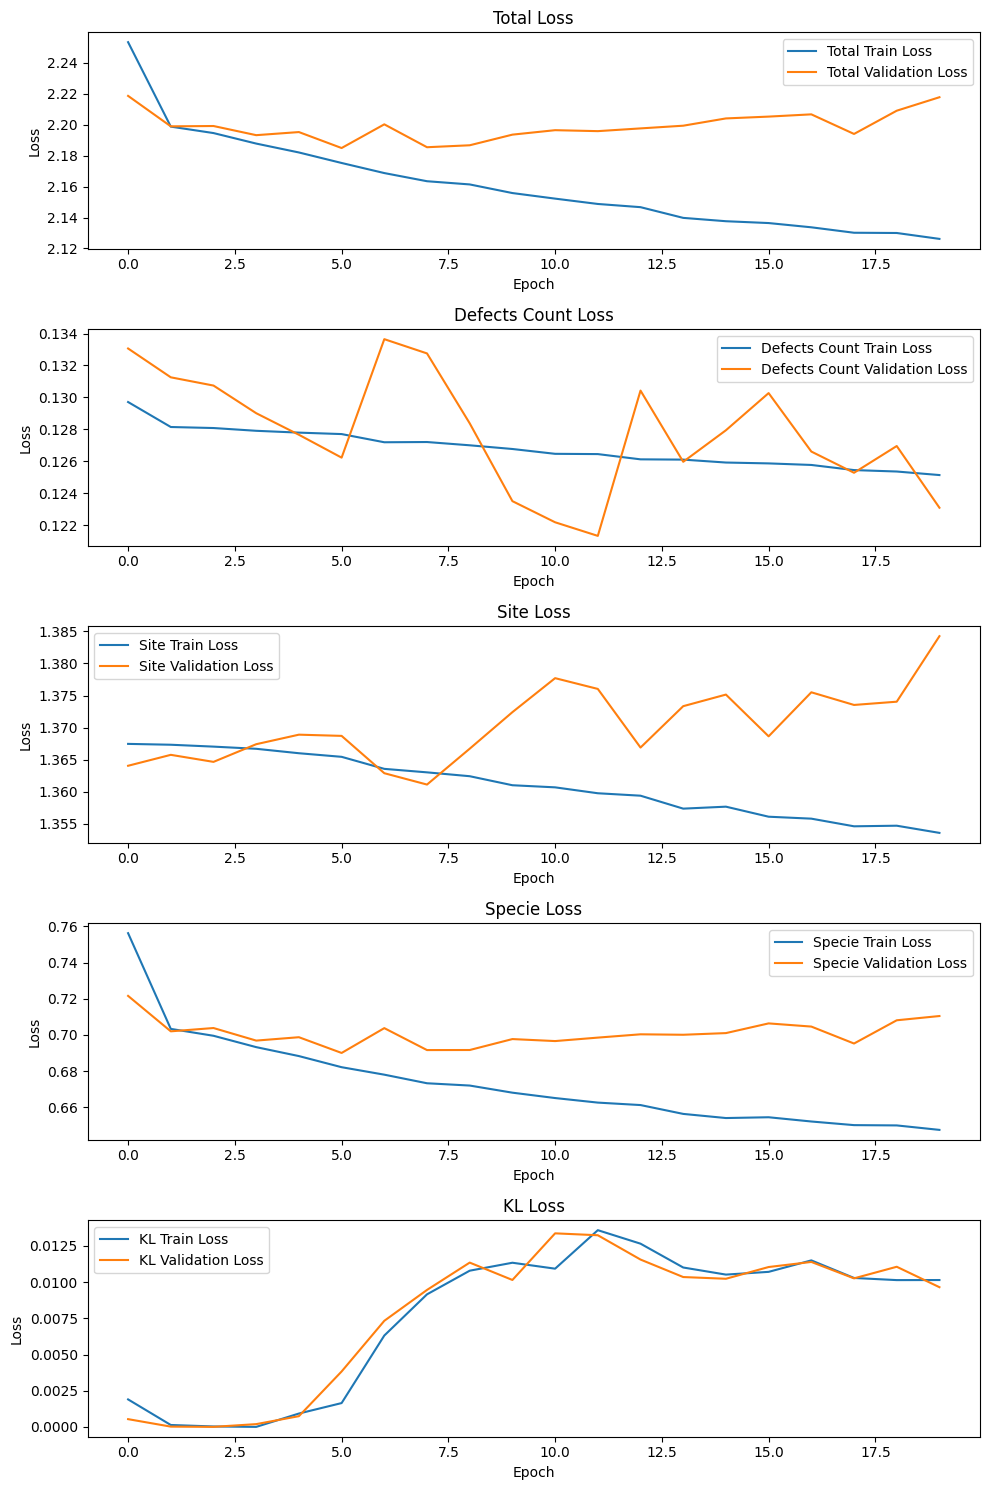

In [13]:
# Plot metrics
fig, axs = plt.subplots(5, 1, figsize=(10, 15))

axs[0].plot(totals, label='Total Train Loss')
axs[0].plot(totals_v, label='Total Validation Loss')
axs[0].set_xlabel('Epoch')
axs[0].set_ylabel('Loss')
axs[0].set_title('Total Loss')
axs[0].legend()

axs[1].plot(counts, label='Defects Count Train Loss')
axs[1].plot(counts_v, label='Defects Count Validation Loss')
axs[1].set_xlabel('Epoch')
axs[1].set_ylabel('Loss')
axs[1].set_title('Defects Count Loss')
axs[1].legend()

axs[2].plot(ss, label='Site Train Loss')
axs[2].plot(ss_v, label='Site Validation Loss')
axs[2].set_xlabel('Epoch')
axs[2].set_ylabel('Loss')
axs[2].set_title('Site Loss')
axs[2].legend()

axs[3].plot(sps, label='Specie Train Loss')
axs[3].plot(sps_v, label='Specie Validation Loss')
axs[3].set_xlabel('Epoch')
axs[3].set_ylabel('Loss')
axs[3].set_title('Specie Loss')
axs[3].legend()

axs[4].plot(kls, label='KL Train Loss')
axs[4].plot(kls_v, label='KL Validation Loss')
axs[4].set_xlabel('Epoch')
axs[4].set_ylabel('Loss')
axs[4].set_title('KL Loss')
axs[4].legend()

plt.tight_layout()
plt.show()

## Inverse Design

In [17]:
def gen_tensor(model, reference_structure, target_band_gap, device = "cpu"):
    model.eval()
    model.to(device)

    with torch.no_grad():
        # the_lattice = reference_structure.lattice
        ref_material = reference_structure.reduced_formula
        out_sites = len(reference_structure)
    
        condition = get_globals(ref_material, target_band_gap)
        
        the_z = torch.randn(1, 32, device=device)
        the_condition = torch.tensor(condition*1, dtype=torch.float).unsqueeze(0).to(device=device)
        the_mask = torch.tensor(get_mask(reference_structure), dtype=torch.bool)
        
        # Generated Edge Indices
        '''nodes = [i for i in range(out_sites)]
        nodes = [nodes for _ in range(out_sites)]
        adj = torch.tensor(nodes, dtype=torch.float)
        the_edge_index, edge_attr = dense_to_sparse(adj)'''
    
        # Run decoder
        defective_tensors = model.decoder(the_z, the_condition, out_sites, the_mask)
        # defective_tensors = defective_tensors.view((out_sites, (1 + self.mask_dim)))

    return defective_tensors


def gen_structure(ref_structure, gen_tensor):
    all_sites = []
    ref_coords = ref_structure.frac_coords
    ref_elements = [site.specie for site in ref_structure.sites]
    structure_lattice = ref_structure.lattice
    the_idx = 0
    
    for row in gen_tensor:
        row = row.detach().cpu()

        the_site = row[0]
        site_state = torch.round(torch.sigmoid(the_site))

        if site_state == 0: # Normal site
            the_site = PeriodicSite(
                species= ref_elements[the_idx],
                coords= ref_coords[the_idx],
                coords_are_cartesian= False,
                lattice= structure_lattice
                )
        else: 
            logit_masks = row[1:]    
    
            cls_idx = int(logit_masks.argmax().item()) # 0 = vacancy, 1..118 = element
        
            the_site = PeriodicSite(
                species= Element.from_Z(cls_idx).symbol if cls_idx > 0 else DummySpecie("X"),
                coords= ref_coords[the_idx],
                coords_are_cartesian= False,
                lattice= structure_lattice
                )

        all_sites.append(the_site)
        the_idx +=1

    result_structure = Structure.from_sites(all_sites)

    return result_structure

def get_clean_defective(full_defective_structure, save=False):
    all_elements = [Element.from_Z(z) for z in range(1, 119)]

    unwanted_sites_index = []

    idx = 0
    
    for site in full_defective_structure.sites:
        if site.specie not in all_elements:
            unwanted_sites_index.append(idx)
        idx += 1
    
    new_defective_structure = full_defective_structure.remove_sites(unwanted_sites_index)

    if save:
        writer = CifWriter(new_defective_structure)
        writer.write_file(f"{gen_data}/{new_defective_structure.formula}.cif")

    return new_defective_structure

def get_visualization(full_defective_structure, pristine_structure):
    
    cloud = get_cloud(full_defective_structure, pristine_structure)

    defective = get_clean_defective(full_defective_structure)

    # if vis:
    fig, num = plt.subplots(1,3, figsize=(15,5))
    # Visualize the pristine structure
    new_pristine = AseAtomsAdaptor.get_atoms(pristine_structure)
    plot_atoms(new_pristine, num[0])
    num[0].set_title("Structure without defects")

    # Visualize the defective structure
    new_defective = AseAtomsAdaptor.get_atoms(defective)
    plot_atoms(new_defective, num[1])
    num[1].set_title("Structure with defects")

    # Visualize the structure without defects
    new_cloud = AseAtomsAdaptor.get_atoms(cloud)
    plot_atoms(new_cloud, num[2])
    num[2].set_title("Defects only structure")

In [18]:
comb_df = pd.read_csv("Final_Dataset/combined/combined_data.csv")

def test_from_df(the_material):

    sample_df = comb_df[comb_df["dataset_material"] == f"high_{the_material}"]
    
    choose_sample = random.randint(0,len(sample_df)-1)

    sample_row = sample_df.iloc[choose_sample]

    # Get required attributes from sample row
    sample_dataset_material = sample_row["dataset_material"]
    sample_id = sample_row["_id"]

    # Get defective structure
    clean_defective_path = f"{original_data}/{sample_dataset_material}/cifs/{sample_id}.cif"
    clean_defective_structure = Structure.from_file(clean_defective_path)

    # Get reference structure
    pristine_path = f"{final_data}/ref_cifs/{sample_dataset_material}.cif"
    pristine_structure = Structure.from_file(pristine_path)

    # Get Full Defective Structure
    full_defective_structure  = get_full_defective(pristine_structure, clean_defective_structure)

    sample_bgv = sample_row["band_gap_value"]
    print(f"Target Band Gap  : {sample_bgv}\n")

    print("TARGET STRUCTURE")
    print(f"Structure Formula: {full_defective_structure.formula}")

    sample_defects_count = sample_row["defect_sites"]
    print(f"Defects Count    : {sample_defects_count}\n")

    generated_tensor    = gen_tensor(model, pristine_structure, sample_bgv, "cpu")
    generated_structure = gen_structure(pristine_structure, generated_tensor)

    print("PREDICTED STRUCTURE")
    print(f"Structure Formula: {generated_structure.formula}")

    gen_cloud = get_cloud(generated_structure, pristine_structure)
    print(f"Defects Count    : {len(gen_cloud)}")


    return pristine_structure, full_defective_structure, generated_structure, sample_bgv



/home/amutua/inverse/lib/python3.10/site-packages/pymatgen/core/structure.py:3109: UserWarning: Issues encountered while parsing CIF: 47 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  struct = parser.parse_structures(primitive=primitive)[0]
/home/amutua/inverse/lib/python3.10/site-packages/pymatgen/core/structure.py:3109: UserWarning: Issues encountered while parsing CIF: 48 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  struct = parser.parse_structures(primitive=primitive)[0]


Target Band Gap  : 0.2563000000000031

TARGET STRUCTURE
Structure Formula: X2 Mo61 W1 Se1 S127
Defects Count    : 4.0

PREDICTED STRUCTURE
Structure Formula: X1 Mo63 Se1 S127
Defects Count    : 2
The Standard Structure
The Generated Structure


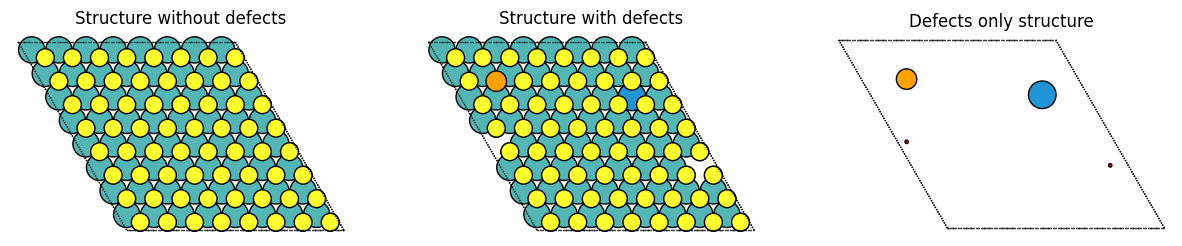

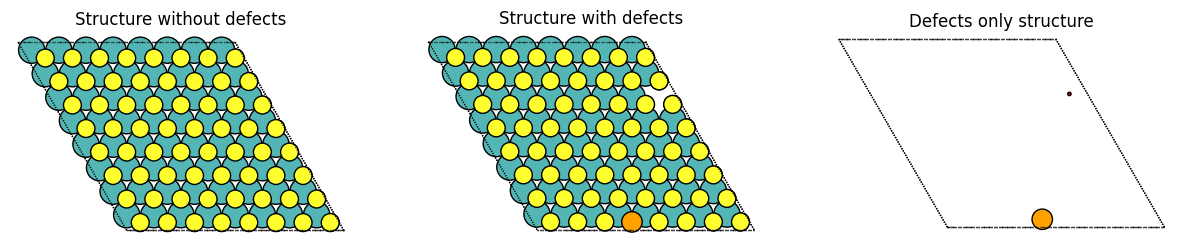

In [20]:
original_structure, target_structure, generated_structure, tbgv = test_from_df("MoS2")

# the_cloud = get_cloud(generated_structure, original_structure)

print("The Standard Structure")
get_visualization(target_structure, original_structure)

print("The Generated Structure")
get_visualization(generated_structure, original_structure)

## Test generated structure on GNN Model

In [21]:
import models
import graphy_gnn

# Load Model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
the_model = models.GNNModel1().to(device)
model_path = "Final_Dataset/gnn models/GNNModel1.pth"
the_model.load_state_dict(torch.load(model_path))

# Make Prediction

# Prepare Generated Structure
defective_structure = get_clean_defective(generated_structure)

defects_structure = graphy_gnn.get_defects_structure(defective_structure, original_structure)

nodes = graphy_gnn.get_nodes(defects_structure)
edges, edge_features = graphy_gnn.get_edges_and_features(original_structure, defects_structure)
global_features = graphy_gnn.get_globals(original_structure, defective_structure, defects_structure)
target = tbgv

the_data = Data(
    x=torch.tensor(nodes, dtype=torch.float),
    edge_index=torch.tensor(edges, dtype=torch.long),
    edge_attr=torch.tensor(edge_features, dtype=torch.float),
    u=torch.tensor(global_features, dtype=torch.float).unsqueeze(0),
    y=torch.tensor(target, dtype=torch.float).unsqueeze(0)
)

attempt = DataLoader([the_data], batch_size=1, shuffle=False)

# Make prediction
the_prediction, the_target = models.predict(the_model, attempt, device)
print(f"Predicted Band Gap: {the_prediction[0]}")
print(f"Target Band Gap: {the_target[0]}")

Predicted Band Gap: -0.11625486612319946
Target Band Gap: 0.2563000023365021


## Save Generated Structure

In [23]:
# print(def_structure(generated_structure))